จงดาวน์โหลด data set จากที่นี่
https://drive.google.com/file/d/1OpFjSPrnSpcqEIJGvCbNXgDD9GkKkZYr/view?usp=sharing


In [2]:
import pandas
df = pandas.read_csv("speeddating.csv")

จงแสดงข้อมูลคอลัมภ์ทั้งหมด จำนวนข้อมูล

In [7]:
print(df.columns)
print(df.shape)

Index(['has_null', 'wave', 'gender', 'age', 'age_o', 'd_age', 'd_d_age',
       'race', 'race_o', 'samerace',
       ...
       'd_expected_num_interested_in_me', 'd_expected_num_matches', 'like',
       'guess_prob_liked', 'd_like', 'd_guess_prob_liked', 'met', 'decision',
       'decision_o', 'match'],
      dtype='object', length=123)
(8378, 123)


จงแสดงคอลัมภ์ใดมี missing value บ้างหรือไม่

In [8]:
df.isnull().sum()

has_null                0
wave                    0
gender                  0
age                    95
age_o                 104
                     ... 
d_guess_prob_liked      0
met                   375
decision                0
decision_o              0
match                   0
Length: 123, dtype: int64

จง drop แถว (row) ที่มีค่า null เก็บในตัวแปร d1 พร้อมแสดง จำนวนแถวที่เหลือหลังทำการ drop

In [9]:
d1 = df.dropna()
d1.shape

(1048, 123)

จงใช้ข้อมูลจาก df สร้าง histogram จากคอลัมภ์ attractive

(array([  20.,  145.,  238.,  642.,    0., 1100., 2914., 2217.,  729.,
         268.]),
 array([ 2. ,  2.8,  3.6,  4.4,  5.2,  6. ,  6.8,  7.6,  8.4,  9.2, 10. ]),
 <BarContainer object of 10 artists>)

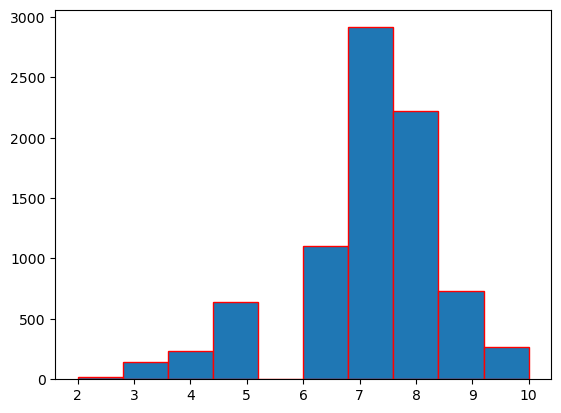

In [12]:
import matplotlib.pyplot as plt

plt.hist(df['attractive'], edgecolor = 'red')

จงใช้ข้อมูลจาก df หา correlation ระหว่าง

1.   expected_happy_with_sd_people
2.   expected_num_interested_in_me
3.   expected_num_matches
4.   like
5.   guess_prob_liked



In [17]:
d2 = (df[["expected_happy_with_sd_people", "expected_num_interested_in_me", "expected_num_matches", "like", "guess_prob_liked"]])
d2.corr().style.background_gradient(cmap="Blues")

,expected_happy_with_sd_people,expected_num_interested_in_me,expected_num_matches,like,guess_prob_liked
expected_happy_with_sd_people,1.000000,0.245687,0.204273,0.106162,0.121764
expected_num_interested_in_me,0.245687,1.000000,0.376534,0.107154,0.349526
expected_num_matches,0.204273,0.376534,1.000000,0.154833,0.332148
like,0.106162,0.107154,0.154833,1.000000,0.463902
guess_prob_liked,0.121764,0.349526,0.332148,0.463902,1.000000


ใช้รูป [นกแก้ว](https://drive.google.com/file/d/1L6TFO-GoYwdrco7dbBsbAdK7O3ZqvycY/view?usp=sharing) นี้ หา HOG

(137, 205, 3)


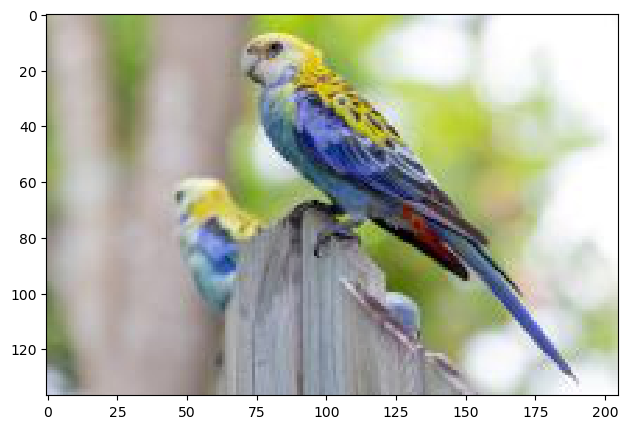

In [12]:
from skimage.io import imread, imshow
from skimage.transform import resize
from skimage.feature import hog
import matplotlib.pyplot as plt
%matplotlib inline
import skimage.io

#reading the image
image = imread('fe-image67s.jpg')
imshow(image)
print(image.shape)

(128, 64, 3)


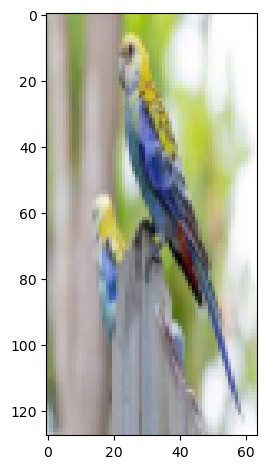

In [13]:
#resizing image
resized_img = skimage.transform.resize(image, (128,64))
skimage.io.imshow(resized_img)
print(resized_img.shape)

In [14]:
#creating hog features
fd, hog_image = skimage.feature.hog(resized_img, 
                                    orientations=9,
                                    pixels_per_cell = (8, 8), 
                                    cells_per_block=(2, 2), 
                                    visualize=True,
                                    channel_axis=-1)

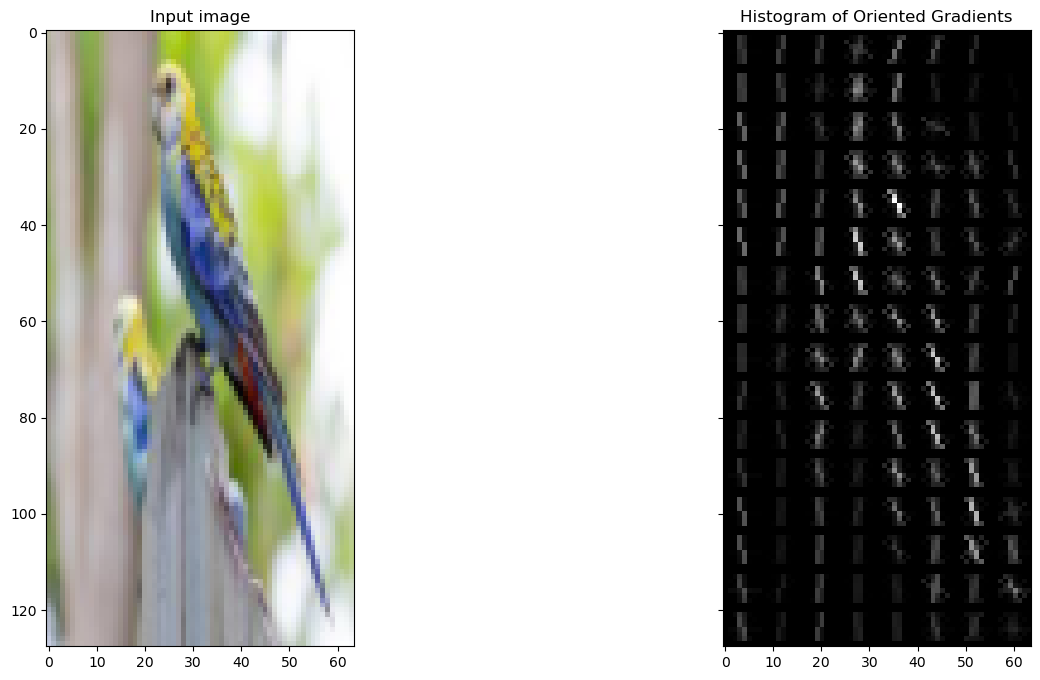

In [15]:
from skimage import exposure

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharex=True, sharey=True)

ax1.imshow(resized_img, cmap=plt.cm.gray)
ax1.set_title('Input image')

# Rescale histogram for better display
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

ax2.imshow(hog_image_rescaled, cmap=plt.cm.gray)
ax2.set_title('Histogram of Oriented Gradients')

plt.show()

ใช้ไฟล์เสียง นี้ หา melspectogram

In [43]:
pip install librosa

Note: you may need to restart the kernel to use updated packages.


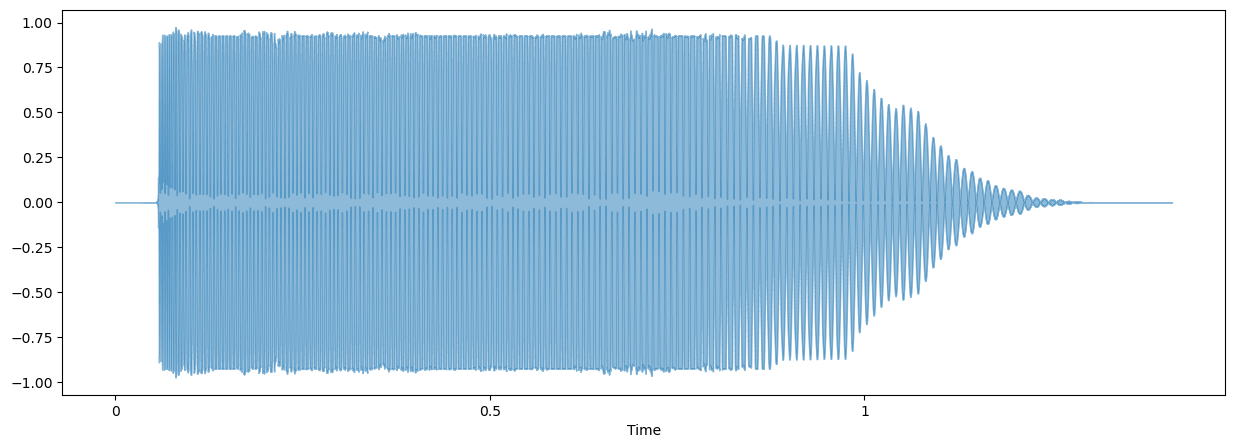

In [50]:
import matplotlib.pyplot as plt
import numpy as np
import librosa, librosa.display, librosa.feature
sound_file = "drum-dj.wav"
wav,wav_sr = librosa.load(sound_file)
# visualize the waveforms
plt.figure(figsize=(15,5))
librosa.display.waveshow(wav, alpha=0.5)

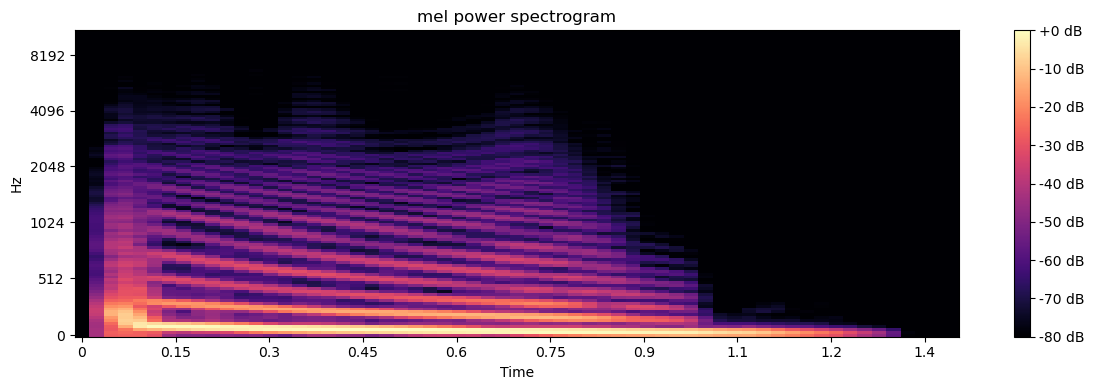

In [51]:
S = librosa.feature.melspectrogram(y=wav, sr=wav_sr, n_mels=128)

log_S = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(12,4))

librosa.display.specshow(log_S, sr=wav_sr, x_axis='time', y_axis='mel')

plt.title('mel power spectrogram')

plt.colorbar(format='%+02.0f dB')

plt.tight_layout()